# K-Nearest Neighbors (KNN) Regressor – Abdulmohsen Almunayes

This notebook trains and evaluates a KNN Regressor on the Medical Insurance dataset.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from joblib import dump
from pathlib import Path

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance

PLOTS_DIR = (Path.cwd().parent / "EDA")
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

def plot_pred_vs_actual(y_true, y_pred, title, fname):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=12, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "--")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Actual charges"); plt.ylabel("Predicted charges")
    plt.title(title)
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def plot_residuals(y_true, y_pred, title, fname):
    resid = y_true - y_pred
    plt.figure(figsize=(6,3.8))
    plt.scatter(y_pred, resid, s=12, alpha=0.6)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Predicted charges"); plt.ylabel("Residual (y - ŷ)")
    plt.title(title)
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def plot_residual_hist(y_true, y_pred, title, fname):
    resid = y_true - y_pred
    plt.figure(figsize=(6,3.8))
    plt.hist(resid, bins=30)
    plt.title(title); plt.xlabel("Residual"); plt.ylabel("Count")
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def plot_learning_curve(estimator, X, y, title, fname):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, shuffle=True, random_state=42
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -test_scores.mean(axis=1)
    plt.figure(figsize=(6,3.8))
    plt.plot(train_sizes, train_rmse, marker="o", label="Train RMSE")
    plt.plot(train_sizes, val_rmse, marker="o", label="CV RMSE")
    plt.xlabel("Training examples"); plt.ylabel("RMSE")
    plt.title(title); plt.legend()
    plt.tight_layout(); plt.savefig(PLOTS_DIR / fname, dpi=150); plt.show()

def get_feature_names_from_pipe(pipe):
    return pipe.named_steps["prep"].get_feature_names_out()

In [3]:
df = pd.read_csv("../insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X = df.drop(columns=["charges"])
y = df["charges"]

categorical = ["sex", "smoker", "region"]
numeric = ["age", "bmi", "children"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = KNeighborsRegressor(n_neighbors=10, weights="distance")
pipe = Pipeline([("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
from math import sqrt

y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 7153.33
RMSE: 10397.64
R²: 0.304


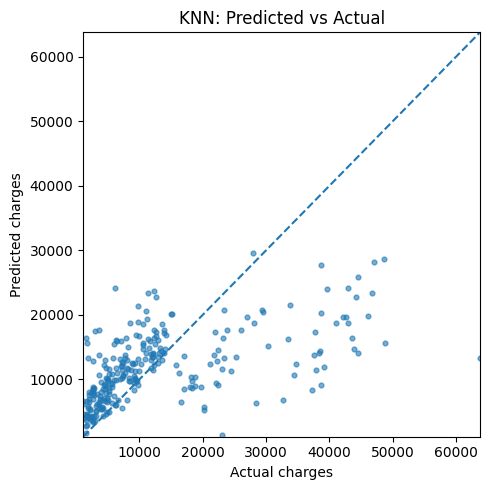

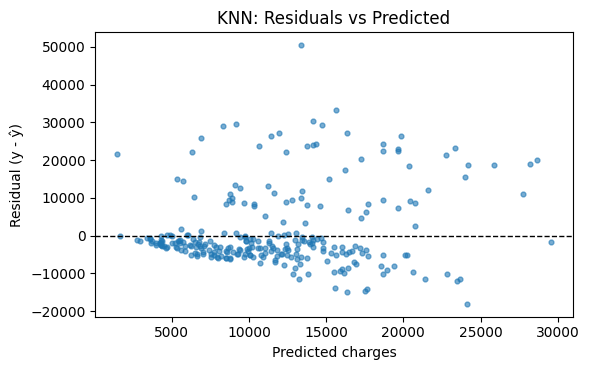

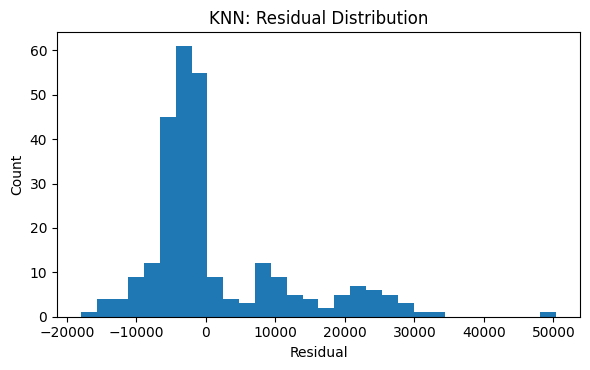

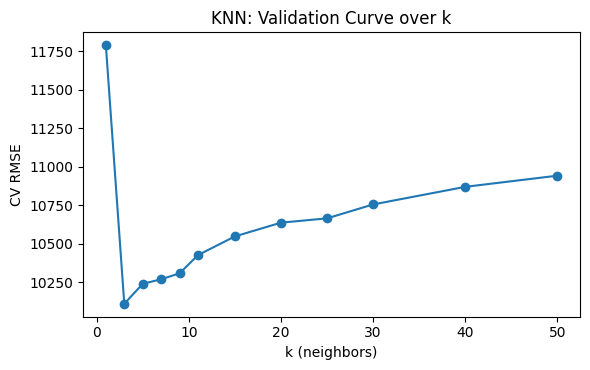

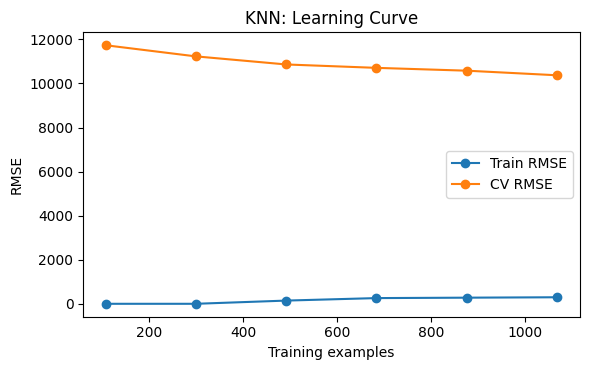

In [7]:
# 1) Predicted vs Actual + residuals
plot_pred_vs_actual(y_test, y_pred, "KNN: Predicted vs Actual", "knn_pred_vs_actual.png")
plot_residuals(y_test, y_pred, "KNN: Residuals vs Predicted", "knn_residuals_scatter.png")
plot_residual_hist(y_test, y_pred, "KNN: Residual Distribution", "knn_residual_hist.png")

# 2) Validation curve across k (neighbors)
from sklearn.model_selection import cross_val_score

ks = [1,3,5,7,9,11,15,20,25,30,40,50]
cv_scores = []
for k in ks:
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.base import clone
    p2 = Pipeline([("prep", pipe.named_steps["prep"]), ("model", KNeighborsRegressor(n_neighbors=k, weights="distance"))])
    scores = cross_val_score(p2, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_scores.append(-scores.mean())

plt.figure(figsize=(6,3.8))
plt.plot(ks, cv_scores, marker="o")
plt.xlabel("k (neighbors)"); plt.ylabel("CV RMSE")
plt.title("KNN: Validation Curve over k")
plt.tight_layout(); plt.savefig(PLOTS_DIR / "knn_validation_curve.png", dpi=150); plt.show()

# 3) Learning curve
plot_learning_curve(pipe, X, y, "KNN: Learning Curve", "knn_learning_curve.png")

In [8]:
import os
os.makedirs("../models", exist_ok=True)

dump(pipe, "../models/knn_regressor.joblib")
pd.DataFrame([{
    "Model": "KNN Regressor",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}]).to_csv("../models/knn_regressor_metrics.csv", index=False)